# Assignment Instructions - Part 3: Parameter Recovery

In this part we focus on estimating model parameters when the model form is known but the parameter values are hidden.

The big idea is to treat this like a debugging task: test candidate parameters, compare output behavior, and decide which values best explain observed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

from generate_dataset import (
    available_models,
    evaluate_truth,
    generate_dataset,
    generate_truth_dataset,
)

sp.init_printing()

## Start Here

We will do this in four small steps:

1. Generate one synthetic dataset with known truth metadata.
2. Run a brute-force search over candidate parameters.
3. Compare recovered parameters against truth.
4. Use the plot and error value to reason about trust in the recovered model.

In [2]:
# Generate one synthetic dataset
data, truth = generate_dataset(
    model_name="exponential",
    seed=420,
    n_points=60,
    noise_fraction=0.10,
 )

display(data.head())
truth

,x,y
0,1.000000,47.936733
1,1.322034,42.233731
2,1.644068,37.003409
3,1.966102,31.454600
4,2.288136,27.297701


{'model_name': 'exponential',
 'parameters': {'A': 79.96840826135686, 'k': 0.47513005448377715},
 'seed': 420,
 'noise_fraction': 0.1,
 'n_points': 60}

### Parameter Recovery Starter

Use the starter code below to recover parameters with a brute-force search, then compare best-fit values with truth.

TODO: Before running the search, discuss in your group which parameter (`P0` or `r`) you think will be harder to recover under noise, and why.

In [3]:
# Brute-force parameter search (exponential model)
x_obs = data["x"].to_numpy()
y_obs = data["y"].to_numpy()

def exp_model(x: np.ndarray, p0: float, r_value: float) -> np.ndarray:
    return p0 * np.exp(r_value * x)

def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

p0_grid = np.linspace(20, 200, 120)
r_grid = np.linspace(0.01, 0.30, 120)

best = {"error": np.inf, "P0": None, "r": None}
for p0_val in p0_grid:
    for r_val in r_grid:
        err = mse(y_obs, exp_model(x_obs, p0_val, r_val))
        if err < best["error"]:
            best = {"error": err, "P0": float(p0_val), "r": float(r_val)}

best

{'error': 403.9210742657032, 'P0': 20.0, 'r': 0.01}

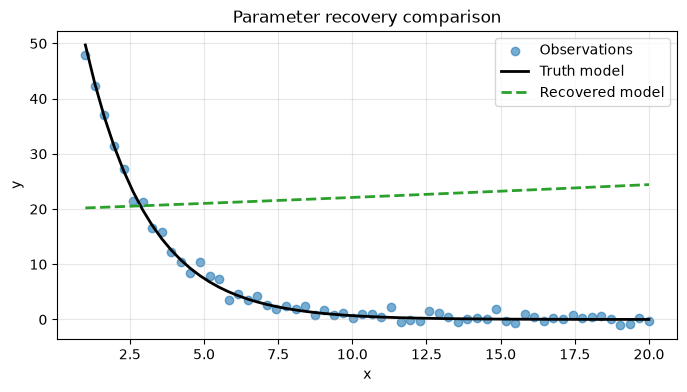

Recovered: {'P0': 20.0, 'r': 0.01}
Truth parameters: {'A': 79.96840826135686, 'k': 0.47513005448377715}
Best MSE: 403.9210742657032


In [4]:
# Compare observations, best-fit model, and truth
best_curve = exp_model(x_obs, best["P0"], best["r"])
truth_curve = evaluate_truth(x_obs, truth)

plt.figure(figsize=(8, 4))
plt.scatter(x_obs, y_obs, alpha=0.6, label="Observations")
plt.plot(x_obs, truth_curve, color="black", lw=2, label="Truth model")
plt.plot(x_obs, best_curve, color="tab:green", lw=2, ls="--", label="Recovered model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter recovery comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Recovered:", {k: v for k, v in best.items() if k != "error"})
print("Truth parameters:", truth["parameters"])
print("Best MSE:", best["error"])

### Discuss and Share

After running the recovery and comparison plot, discuss and be ready to share back:

- Did the recovered parameters match truth closely?
- Which parameter looked more sensitive to noise?
- Could multiple parameter pairs produce similarly good fits?
- What is one debugging step you would add before trusting a recovered model?

# PUT YOUR GROUP ANSWERS HERE

- Matching truth:
- Noise sensitivity notes:
- Multiple-good-fit notes:
- Extra debugging step: